In [3]:
retail = pd.read_csv("../data/processed/retail_price_features.csv")

print("Shape:", retail.shape)

print("\nColumns:")
print(retail.columns.tolist())

display(retail.head())

Shape: (676, 45)

Columns:
['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price', 'Month', 'Year', 'Quarter', 'Is_First_Half', 'Is_Second_Half', 'Avg_Competitor_Price', 'Min_Competitor_Price', 'Max_Competitor_Price', 'Price_Difference', 'Price_Gap_Pct', 'Price_Change', 'Price_Change_Pct', 'Qty_Change_Pct', 'Price_Elasticity', 'Competitive_Position']


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,Avg_Competitor_Price,Min_Competitor_Price,Max_Competitor_Price,Price_Difference,Price_Gap_Pct,Price_Change,Price_Change_Pct,Qty_Change_Pct,Price_Elasticity,Competitive_Position
0,bed1,bed_bath_table,2017-05-01,1,45.95,15.100000,45.95,39,161,2,...,116.950000,45.95,215.000000,-71.000000,-60.709705,0.05,0.108932,NaN,NaN,Below Competitors
1,bed1,bed_bath_table,2017-06-01,3,137.85,12.933333,45.95,39,161,2,...,114.950000,45.95,209.000000,-69.000000,-60.026098,0.00,0.000000,200.000000,NaN,Below Competitors
2,bed1,bed_bath_table,2017-07-01,6,275.70,14.840000,45.95,39,161,2,...,113.616667,45.95,205.000000,-67.666667,-59.556990,0.00,0.000000,100.000000,NaN,Below Competitors
3,bed1,bed_bath_table,2017-08-01,4,183.80,14.287500,45.95,39,161,2,...,111.786601,45.95,199.509804,-65.836601,-58.894895,0.00,0.000000,-33.333333,NaN,Below Competitors
4,bed1,bed_bath_table,2017-09-01,2,91.90,15.100000,45.95,39,161,2,...,99.749570,45.95,163.398710,-53.799570,-53.934638,0.00,0.000000,-50.000000,NaN,Below Competitors


In [4]:
# Step 1: Overall Pricing Statistics

print("Overall Pricing Statistics")
print("=" * 40)

print("\nUnit Price:")
display(retail["unit_price"].describe())

print("\nQuantity Sold:")
display(retail["qty"].describe())

print("\nTotal Price:")
display(retail["total_price"].describe())

print("\nNumber of Products:", retail["product_id"].nunique())
print("Number of Categories:", retail["product_category_name"].nunique())
print("Number of Records:", len(retail))

Overall Pricing Statistics

Unit Price:


count    676.000000
mean     106.496800
std       76.182972
min       19.900000
25%       53.900000
50%       89.900000
75%      129.990000
max      364.000000
Name: unit_price, dtype: float64


Quantity Sold:


count    676.000000
mean      14.495562
std       15.443421
min        1.000000
25%        4.000000
50%       10.000000
75%       18.000000
max      122.000000
Name: qty, dtype: float64


Total Price:


count      676.000000
mean      1422.708728
std       1700.123100
min         19.900000
25%        333.700000
50%        807.890000
75%       1887.322500
max      12095.000000
Name: total_price, dtype: float64


Number of Products: 52
Number of Categories: 9
Number of Records: 676


In [5]:
# Step 2: Category-level Pricing and Demand Analysis

category_summary = (
    retail.groupby("product_category_name")
    .agg(
        Products=("product_id", "nunique"),
        Average_Quantity=("qty", "mean"),
        Total_Quantity=("qty", "sum"),
        Average_Unit_Price=("unit_price", "mean"),
        Average_Total_Price=("total_price", "mean")
    )
    .reset_index()
)

category_summary = category_summary.sort_values(
    "Total_Quantity",
    ascending=False
)

display(category_summary)

,product_category_name,Products,Average_Quantity,Total_Quantity,Average_Unit_Price,Average_Total_Price
5,garden_tools,10,14.987500,2398,80.094699,1022.390875
6,health_beauty,10,14.169231,1842,132.309870,1633.917231
8,watches_gifts,8,13.893204,1431,164.880007,2015.360874
1,computers_accessories,6,16.913043,1167,119.482323,2059.390580
0,bed_bath_table,5,16.819672,1026,78.629278,1558.762623
4,furniture_decor,4,18.625000,894,60.154262,1185.940833
3,cool_stuff,5,9.789474,558,107.857512,1016.777193
7,perfumery,2,9.384615,244,89.348813,781.250769
2,consoles_games,2,10.863636,239,27.033766,263.668182


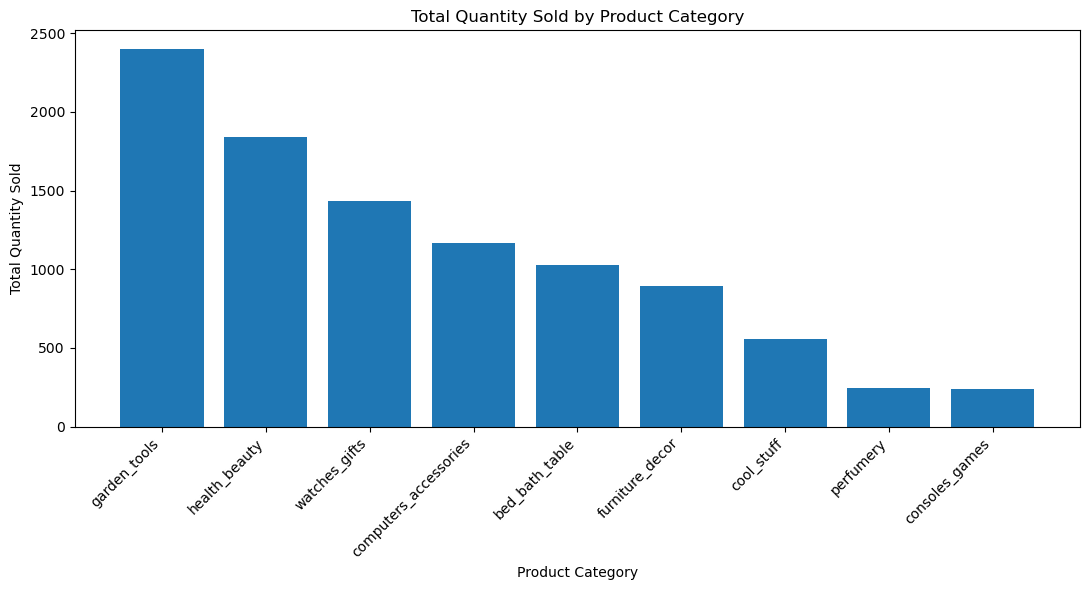

In [6]:
# Total quantity sold by category

plt.figure(figsize=(11, 6))

plt.bar(
    category_summary["product_category_name"],
    category_summary["Total_Quantity"]
)

plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.title("Total Quantity Sold by Product Category")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [7]:
# Step 3: Category-level Price vs Demand Analysis

category_price_demand = (
    retail.groupby("product_category_name")
    .agg(
        Average_Unit_Price=("unit_price", "mean"),
        Average_Quantity=("qty", "mean"),
        Total_Quantity=("qty", "sum")
    )
    .reset_index()
)

display(category_price_demand)

,product_category_name,Average_Unit_Price,Average_Quantity,Total_Quantity
0,bed_bath_table,78.629278,16.819672,1026
1,computers_accessories,119.482323,16.913043,1167
2,consoles_games,27.033766,10.863636,239
3,cool_stuff,107.857512,9.789474,558
4,furniture_decor,60.154262,18.625000,894
5,garden_tools,80.094699,14.987500,2398
6,health_beauty,132.309870,14.169231,1842
7,perfumery,89.348813,9.384615,244
8,watches_gifts,164.880007,13.893204,1431


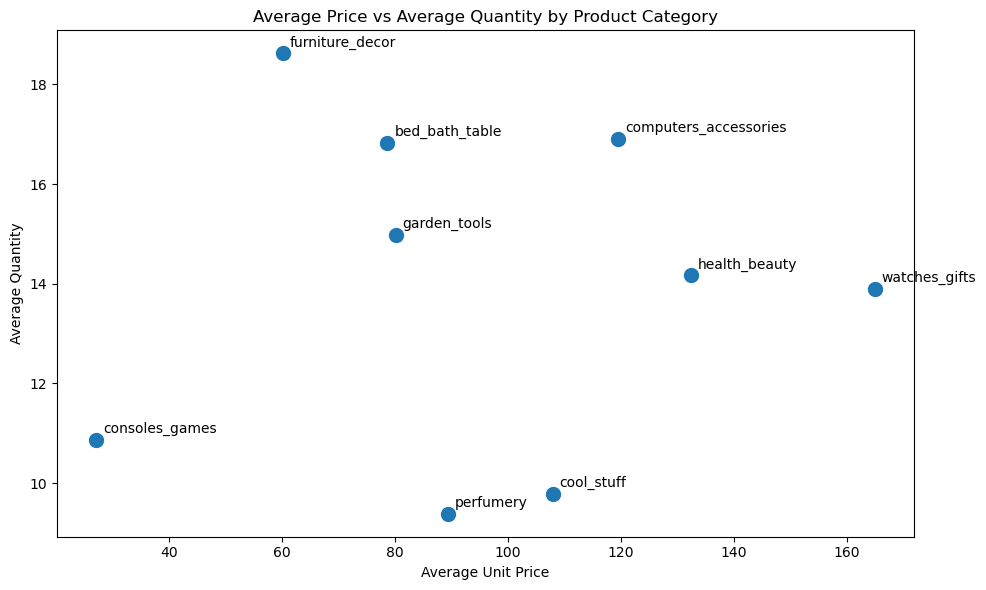

In [8]:
# Average Unit Price vs Average Quantity by Category

plt.figure(figsize=(10, 6))

plt.scatter(
    category_price_demand["Average_Unit_Price"],
    category_price_demand["Average_Quantity"],
    s=100
)

for _, row in category_price_demand.iterrows():
    plt.annotate(
        row["product_category_name"],
        (row["Average_Unit_Price"], row["Average_Quantity"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Unit Price")
plt.ylabel("Average Quantity")
plt.title("Average Price vs Average Quantity by Product Category")

plt.tight_layout()
plt.show()

In [9]:
# Step 4: Monthly Pricing and Demand Trend

monthly_summary = (
    retail.groupby("month_year")
    .agg(
        Average_Unit_Price=("unit_price", "mean"),
        Average_Quantity=("qty", "mean"),
        Total_Quantity=("qty", "sum")
    )
    .reset_index()
    .sort_values("month_year")
)

display(monthly_summary)

,month_year,Average_Unit_Price,Average_Quantity,Total_Quantity
0,2017-01-01,207.445000,4.500000,9
1,2017-02-01,127.827143,3.888889,35
2,2017-03-01,122.586615,7.769231,101
3,2017-04-01,119.288667,8.066667,121
4,2017-05-01,104.785769,11.100000,222
5,2017-06-01,112.152081,9.320000,233
6,2017-07-01,105.111896,12.212121,403
7,2017-08-01,114.737339,13.378378,495
8,2017-09-01,112.336313,12.500000,450
9,2017-10-01,113.623544,12.790698,550


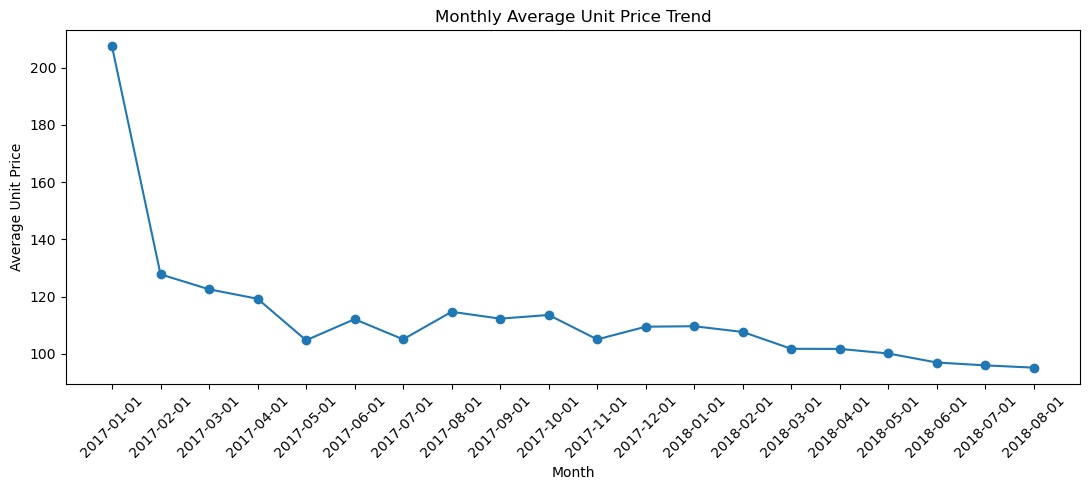

In [10]:
# Monthly Average Unit Price Trend

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_summary["month_year"],
    monthly_summary["Average_Unit_Price"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Unit Price")
plt.title("Monthly Average Unit Price Trend")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

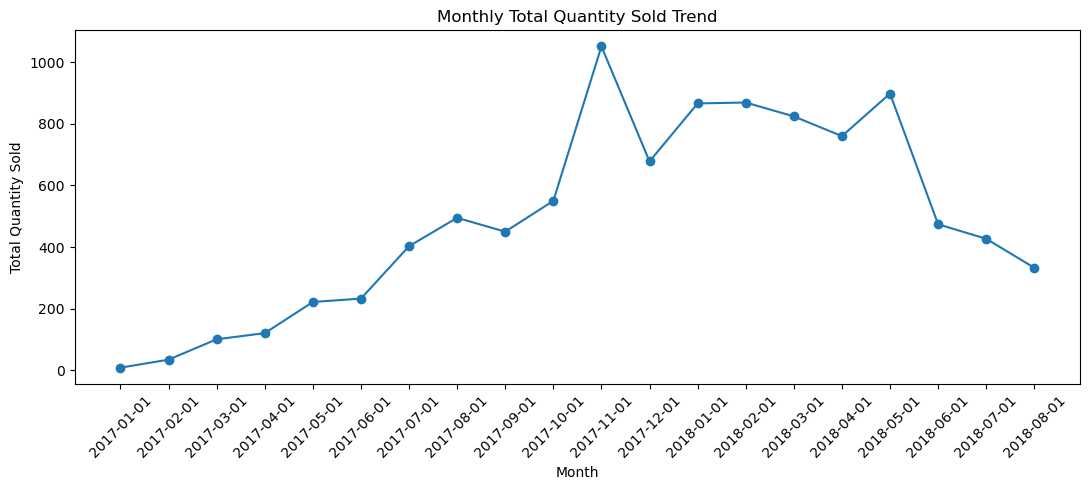

In [11]:
# Monthly Total Quantity Trend

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_summary["month_year"],
    monthly_summary["Total_Quantity"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.title("Monthly Total Quantity Sold Trend")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# Step 5: Competitive Price Position Analysis

competitive_summary = (
    retail.groupby("Competitive_Position")
    .agg(
        Records=("product_id", "count"),
        Average_Unit_Price=("unit_price", "mean"),
        Average_Competitor_Price=("Avg_Competitor_Price", "mean"),
        Average_Price_Gap_Pct=("Price_Gap_Pct", "mean"),
        Average_Quantity=("qty", "mean"),
        Total_Quantity=("qty", "sum")
    )
    .reset_index()
)

display(competitive_summary)

,Competitive_Position,Records,Average_Unit_Price,Average_Competitor_Price,Average_Price_Gap_Pct,Average_Quantity,Total_Quantity
0,Above Competitors,283,154.796462,86.933673,99.604289,12.462898,3527
1,Below Competitors,193,65.569570,91.757495,-30.584428,14.901554,2876
2,Similar to Competitors,200,77.647554,77.505850,0.185097,16.980000,3396


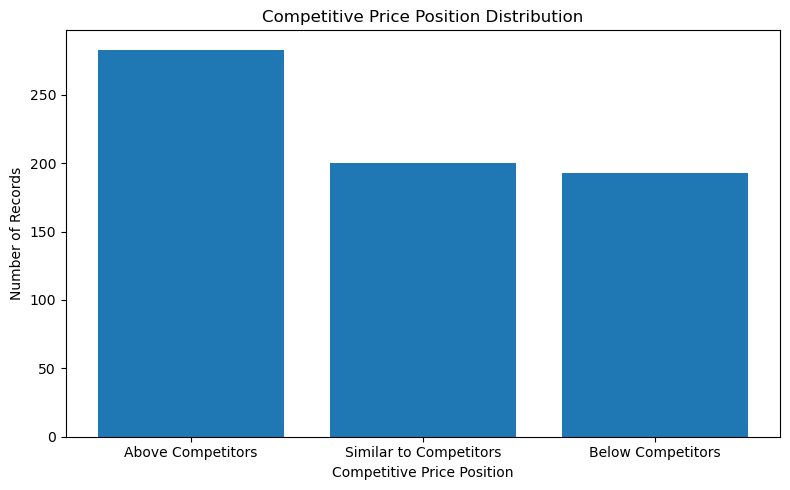

In [13]:
# Competitive Position Distribution

position_counts = retail["Competitive_Position"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    position_counts.index,
    position_counts.values
)

plt.xlabel("Competitive Price Position")
plt.ylabel("Number of Records")
plt.title("Competitive Price Position Distribution")

plt.tight_layout()
plt.show()

In [14]:
# Step 6: Load Product-Level Price Elasticity Summary

elasticity_summary = pd.read_csv(
    "../data/processed/product_elasticity_summary.csv"
)

print("Shape:", elasticity_summary.shape)

display(elasticity_summary.head(10))

Shape: (51, 9)


,product_id,Elasticity_Observations,Mean_Elasticity,Median_Elasticity,Min_Elasticity,Max_Elasticity,Abs_Median_Elasticity,Elasticity_Type,Reliability
0,bed1,3,3.795997,-0.000000,-22.615213,34.003203,0.000000,Inelastic,Lower
1,bed2,7,-14.749338,5.944068,-203.157846,35.023542,5.944068,Elastic,Moderate
2,bed3,5,-53.273727,-19.159814,-163.555556,-0.000000,19.159814,Elastic,Moderate
3,bed4,3,-10.001602,-11.475000,-15.809596,-2.720209,11.475000,Elastic,Lower
4,bed5,4,-142.992489,-126.950021,-322.500000,4.430085,126.950021,Elastic,Moderate
5,computers1,10,-70.933761,-9.137466,-354.649773,7.908333,9.137466,Elastic,Higher
6,computers2,7,17.482436,8.060606,-21.101730,117.600633,8.060606,Elastic,Moderate
7,computers3,8,184.393781,0.875257,-201.128049,1773.333333,0.875257,Inelastic,Higher
8,computers4,14,-86.391941,-2.022552,-1279.520000,34.808572,2.022552,Elastic,Higher
9,computers5,6,168.525919,-3.082880,-1257.900000,2397.000000,3.082880,Elastic,Moderate


Elasticity_Type
Elastic      43
Inelastic     8
Name: count, dtype: int64

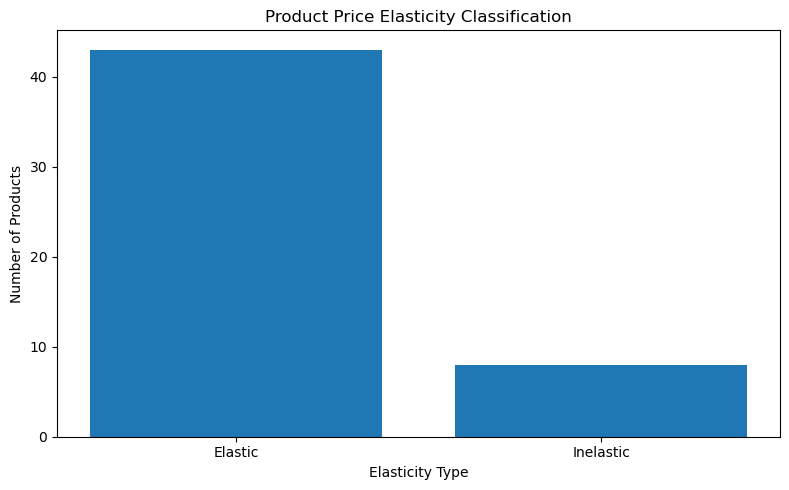

In [15]:
# Elasticity Type Distribution

elasticity_counts = (
    elasticity_summary["Elasticity_Type"]
    .value_counts()
)

display(elasticity_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    elasticity_counts.index,
    elasticity_counts.values
)

plt.xlabel("Elasticity Type")
plt.ylabel("Number of Products")
plt.title("Product Price Elasticity Classification")

plt.tight_layout()
plt.show()

In [16]:
# Step 7: Products with Highest Absolute Price Elasticity

top_elastic_products = (
    elasticity_summary
    .sort_values("Abs_Median_Elasticity", ascending=False)
    .head(10)
)

display(
    top_elastic_products[
        [
            "product_id",
            "Elasticity_Observations",
            "Median_Elasticity",
            "Abs_Median_Elasticity",
            "Elasticity_Type",
            "Reliability"
        ]
    ]
)

,product_id,Elasticity_Observations,Median_Elasticity,Abs_Median_Elasticity,Elasticity_Type,Reliability
32,health1,1,-849.400000,849.400000,Elastic,Lower
10,computers6,1,-706.666293,706.666293,Elastic,Lower
15,cool3,4,-230.225877,230.225877,Elastic,Moderate
45,watches3,3,131.039999,131.039999,Elastic,Lower
4,bed5,4,-126.950021,126.950021,Elastic,Moderate
41,perfumery1,3,86.554286,86.554286,Elastic,Lower
42,perfumery2,10,49.137745,49.137745,Elastic,Higher
38,health7,3,-36.749702,36.749702,Elastic,Lower
20,furniture3,5,-32.680222,32.680222,Elastic,Moderate
34,health2,2,29.646741,29.646741,Elastic,Lower


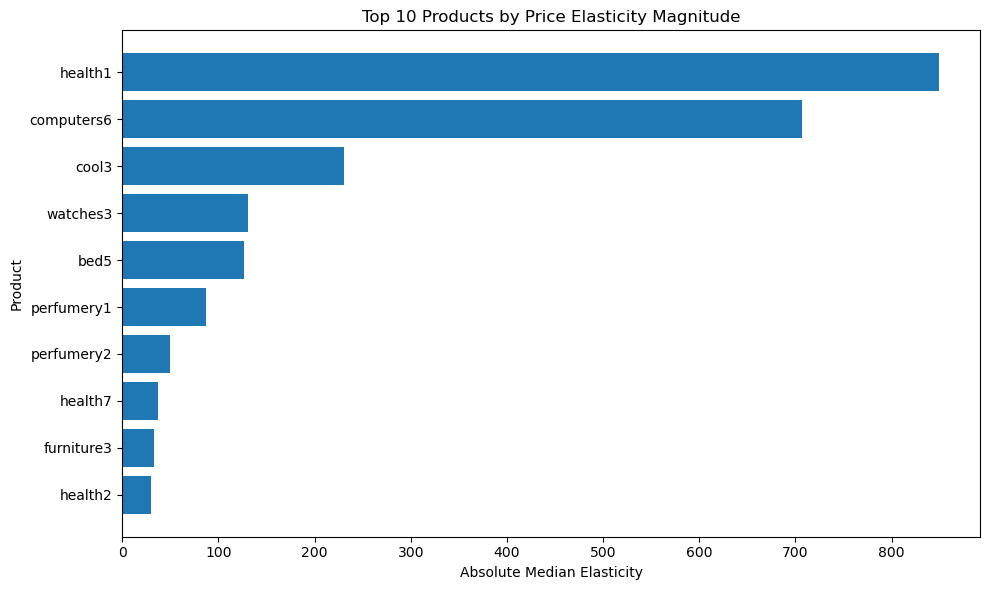

In [17]:
# Top 10 Products by Absolute Median Elasticity

plt.figure(figsize=(10, 6))

plt.barh(
    top_elastic_products["product_id"],
    top_elastic_products["Abs_Median_Elasticity"]
)

plt.xlabel("Absolute Median Elasticity")
plt.ylabel("Product")
plt.title("Top 10 Products by Price Elasticity Magnitude")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [18]:
# Step 8: Elasticity vs Reliability

reliability_summary = (
    elasticity_summary
    .groupby("Reliability")
    .agg(
        Products=("product_id", "count"),
        Average_Observations=("Elasticity_Observations", "mean"),
        Median_Absolute_Elasticity=("Abs_Median_Elasticity", "median")
    )
    .reset_index()
)

display(reliability_summary)

,Reliability,Products,Average_Observations,Median_Absolute_Elasticity
0,Higher,15,10.8000,5.822196
1,Lower,16,2.4375,11.558288
2,Moderate,20,5.5500,3.490658


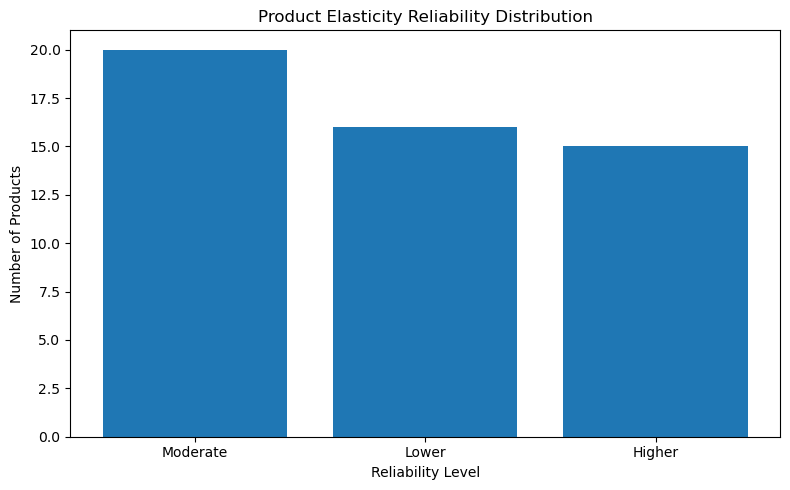

In [19]:
# Number of products by reliability level

reliability_counts = elasticity_summary["Reliability"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    reliability_counts.index,
    reliability_counts.values
)

plt.xlabel("Reliability Level")
plt.ylabel("Number of Products")
plt.title("Product Elasticity Reliability Distribution")

plt.tight_layout()
plt.show()

In [20]:
# Step 9: Pricing Opportunity Analysis

pricing_opportunity = (
    retail.groupby("Competitive_Position")
    .agg(
        Products=("product_id", "nunique"),
        Records=("product_id", "count"),
        Average_Price=("unit_price", "mean"),
        Average_Competitor_Price=("Avg_Competitor_Price", "mean"),
        Average_Price_Gap_Pct=("Price_Gap_Pct", "mean"),
        Average_Quantity=("qty", "mean"),
        Total_Quantity=("qty", "sum")
    )
    .reset_index()
)

display(pricing_opportunity)

,Competitive_Position,Products,Records,Average_Price,Average_Competitor_Price,Average_Price_Gap_Pct,Average_Quantity,Total_Quantity
0,Above Competitors,29,283,154.796462,86.933673,99.604289,12.462898,3527
1,Below Competitors,22,193,65.569570,91.757495,-30.584428,14.901554,2876
2,Similar to Competitors,31,200,77.647554,77.505850,0.185097,16.980000,3396


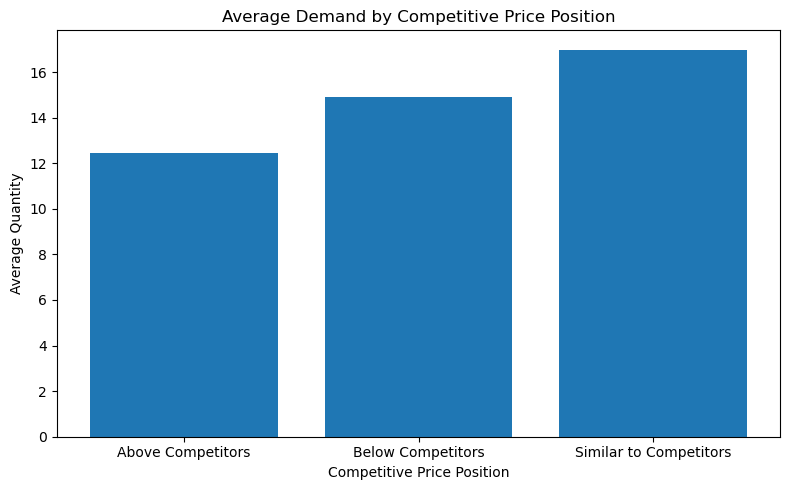

In [21]:
# Compare average quantity across competitive positions

plt.figure(figsize=(8, 5))

plt.bar(
    pricing_opportunity["Competitive_Position"],
    pricing_opportunity["Average_Quantity"]
)

plt.xlabel("Competitive Price Position")
plt.ylabel("Average Quantity")
plt.title("Average Demand by Competitive Price Position")

plt.tight_layout()
plt.show()

In [22]:
# Step 10: Final Pricing Analysis Summary

print("========== FINAL PRICING ANALYSIS SUMMARY ==========\n")

print("1. Overall Pricing")
print(f"Average Unit Price: {retail['unit_price'].mean():.2f}")
print(f"Median Unit Price: {retail['unit_price'].median():.2f}")
print(f"Average Quantity: {retail['qty'].mean():.2f}")

print("\n2. Competitive Position")
for _, row in competitive_summary.iterrows():
    print(
        f"{row['Competitive_Position']}: "
        f"Avg Price = {row['Average_Unit_Price']:.2f}, "
        f"Avg Quantity = {row['Average_Quantity']:.2f}, "
        f"Price Gap = {row['Average_Price_Gap_Pct']:.2f}%"
    )

print("\n3. Elasticity")
print(f"Products analyzed: {len(elasticity_summary)}")
print(
    f"Elastic products: "
    f"{(elasticity_summary['Elasticity_Type'] == 'Elastic').sum()}"
)
print(
    f"Inelastic products: "
    f"{(elasticity_summary['Elasticity_Type'] == 'Inelastic').sum()}"
)

print("\n4. Elasticity Reliability")
print(elasticity_summary["Reliability"].value_counts())

print("\n5. Important Interpretation")
print(
    "Price, competitor positioning, and demand show observable relationships "
    "in the dataset. However, these relationships are observational and "
    "should not be interpreted as causal effects."
)

========== FINAL PRICING ANALYSIS SUMMARY ==========

1. Overall Pricing
Average Unit Price: 106.50
Median Unit Price: 89.90
Average Quantity: 14.50

2. Competitive Position
Above Competitors: Avg Price = 154.80, Avg Quantity = 12.46, Price Gap = 99.60%
Below Competitors: Avg Price = 65.57, Avg Quantity = 14.90, Price Gap = -30.58%
Similar to Competitors: Avg Price = 77.65, Avg Quantity = 16.98, Price Gap = 0.19%

3. Elasticity
Products analyzed: 51
Elastic products: 43
Inelastic products: 8

4. Elasticity Reliability
Reliability
Moderate    20
Lower       16
Higher      15
Name: count, dtype: int64

5. Important Interpretation
Price, competitor positioning, and demand show observable relationships in the dataset. However, these relationships are observational and should not be interpreted as causal effects.


In [23]:
# Final Step: Save Pricing Analysis Outputs

import os

os.makedirs("../data/predictions", exist_ok=True)

category_summary.to_csv(
    "../data/predictions/pricing_category_summary.csv",
    index=False
)

monthly_summary.to_csv(
    "../data/predictions/pricing_monthly_summary.csv",
    index=False
)

competitive_summary.to_csv(
    "../data/predictions/pricing_competitive_summary.csv",
    index=False
)

pricing_opportunity.to_csv(
    "../data/predictions/pricing_opportunity_summary.csv",
    index=False
)

elasticity_summary.to_csv(
    "../data/predictions/pricing_elasticity_summary.csv",
    index=False
)

print("Pricing analysis outputs saved successfully.")

print("\nFiles created:")
print("1. pricing_category_summary.csv")
print("2. pricing_monthly_summary.csv")
print("3. pricing_competitive_summary.csv")
print("4. pricing_opportunity_summary.csv")
print("5. pricing_elasticity_summary.csv")

Pricing analysis outputs saved successfully.

Files created:
1. pricing_category_summary.csv
2. pricing_monthly_summary.csv
3. pricing_competitive_summary.csv
4. pricing_opportunity_summary.csv
5. pricing_elasticity_summary.csv


In [24]:
import os

print("========== PROJECT FILE VERIFICATION ==========\n")

folders = {
    "RAW DATA": "../data/raw",
    "PROCESSED DATA": "../data/processed",
    "PREDICTIONS": "../data/predictions"
}

for folder_name, folder_path in folders.items():
    print(f"\n📁 {folder_name}")
    print("-" * 40)

    if os.path.exists(folder_path):
        files = os.listdir(folder_path)

        if files:
            for file in sorted(files):
                print("✓", file)
        else:
            print("Folder is empty")
    else:
        print("❌ Folder not found")

========== PROJECT FILE VERIFICATION ==========


📁 RAW DATA
----------------------------------------
✓ online_retail_II.csv
✓ retail_price.csv

📁 PROCESSED DATA
----------------------------------------
✓ .ipynb_checkpoints
✓ Untitled.ipynb
✓ monthly_demand_complete.csv
✓ monthly_demand_features.csv
✓ next_month_demand_predictions.csv
✓ online_retail_clean.csv
✓ product_elasticity_summary.csv
✓ retail_price_features.csv

📁 PREDICTIONS
----------------------------------------
✓ business_action_recommendations.csv
✓ final_decision_table.csv
✓ prediction_reliability.csv
✓ prediction_risk_summary.csv
✓ pricing_category_summary.csv
✓ pricing_competitive_summary.csv
✓ pricing_elasticity_summary.csv
✓ pricing_monthly_summary.csv
✓ pricing_opportunity_summary.csv
